In [1]:
# Yahoo Finance verilerini çekmek için gerekli kütüphaneyi kuruyoruz
!pip install yfinance

# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print("Kütüphaneler yüklendi ve içe aktarıldı.")

Kütüphaneler yüklendi ve içe aktarıldı.


In [2]:
# Analiz edeceğimiz şirketlerin kısaltmaları (ticker symbol)
tickers = ['AAPL', 'MSFT'] # Apple ve Microsoft

# 5 yıllık (5y) verileri, bugün (current day) tarihine kadar çekiyoruz
veri = yf.download(tickers, period="5y")

# Sadece Kapanış (Close) fiyatlarını içeren yeni bir DataFrame oluşturuyoruz
fiyatlar = veri['Close']

# Veri setinin ilk 5 satırını görüntüleyerek kontrol ediyoruz
print("--- Hisse Senedi Kapanış Fiyatlarının İlk 5 Satırı ---")
print(fiyatlar.head())

/tmp/ipython-input-3582013068.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  veri = yf.download(tickers, period="5y")
[*********************100%***********************]  2 of 2 completed

--- Hisse Senedi Kapanış Fiyatlarının İlk 5 Satırı ---
Ticker            AAPL        MSFT
Date                              
2020-12-07  120.464714  205.619766
2020-12-08  121.077988  207.270187
2020-12-09  118.547012  203.230530
2020-12-10  119.968254  202.002319
2020-12-11  119.160286  204.631424


In [3]:
# Günlük getiriyi (Daily Returns) hesaplıyoruz.
# Pandas'ın pct_change() fonksiyonu, bir önceki değere göre yüzde kaç değişim olduğunu bulur.
gunluk_getiri = fiyatlar.pct_change()

# İlk satırda her zaman NaN (Boş) olacağı için, ilk 5 satıra tekrar bakalım.
print("--- Hisse Senedi Günlük Getirileri (İlk 5 Satır) ---")
print(gunluk_getiri.head())

# Performans Metriği 1: Ortalama Getiri
print("\n--- Hisse Senedi Ortalama Günlük Getiriler (Yüzde Olarak) ---")
print(gunluk_getiri.mean() * 100)

--- Hisse Senedi Günlük Getirileri (İlk 5 Satır) ---
Ticker          AAPL      MSFT
Date                          
2020-12-07       NaN       NaN
2020-12-08  0.005091  0.008027
2020-12-09 -0.020904 -0.019490
2020-12-10  0.011989 -0.006043
2020-12-11 -0.006735  0.013015

--- Hisse Senedi Ortalama Günlük Getiriler (Yüzde Olarak) ---
Ticker
AAPL    0.082423
MSFT    0.081199
dtype: float64


In [4]:
# Performans Metriği 2: Oynaklık (Risk)
# Oynaklık için standart sapmayı (std) hesaplıyoruz
oynaklik = gunluk_getiri.std() * 100 # Yüzde olarak gösteriyoruz

print("\n--- Hisse Senedi Oynaklıkları (Risk) ---")
print(oynaklik)



--- Hisse Senedi Oynaklıkları (Risk) ---
Ticker
AAPL    1.768161
MSFT    1.621320
dtype: float64


In [5]:
# Her hissenin başlangıç (ilk gün) kapanış fiyatını buluyoruz
ilk_fiyatlar = fiyatlar.iloc[0]

# Normalleştirilmiş Fiyat = (Güncel Fiyat / İlk Fiyat) * 100
normal_fiyatlar = (fiyatlar / ilk_fiyatlar) * 100

print("--- Normalleştirilmiş Fiyatların İlk 5 Satırı (Başlangıç 100) ---")
print(normal_fiyatlar.head())

--- Normalleştirilmiş Fiyatların İlk 5 Satırı (Başlangıç 100) ---
Ticker            AAPL        MSFT
Date                              
2020-12-07  100.000000  100.000000
2020-12-08  100.509090  100.802657
2020-12-09   98.408080   98.838032
2020-12-10   99.587879   98.240711
2020-12-11   98.917170   99.519335


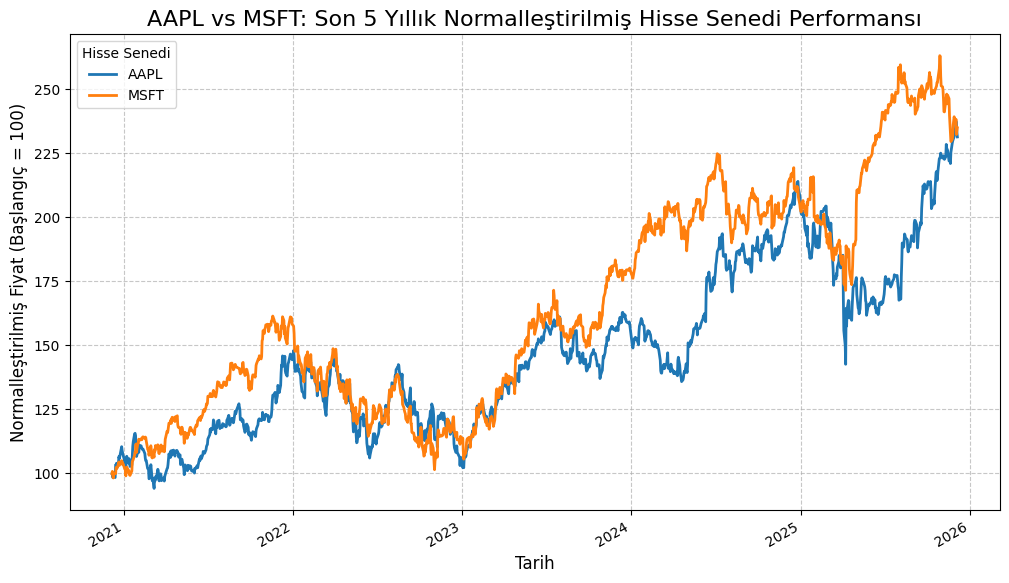

In [6]:
# Grafiğin boyutunu ayarlıyoruz
plt.figure(figsize=(12, 7))

# Çizgi Grafiği Çizme
# Normalleştirilmiş fiyatlar DataFrame'ini doğrudan çizdiriyoruz.
normal_fiyatlar.plot(ax=plt.gca(), linewidth=2)

# Başlıklar ve Etiketler
plt.title('AAPL vs MSFT: Son 5 Yıllık Normalleştirilmiş Hisse Senedi Performansı', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Normalleştirilmiş Fiyat (Başlangıç = 100)', fontsize=12)

# Ek Bilgiler
plt.legend(title='Hisse Senedi') # Hangi çizginin hangi hisseye ait olduğunu gösterir
plt.grid(True, linestyle='--', alpha=0.7) # Grafiğe kılavuz çizgileri ekler
plt.show() # Grafiği göster